230316
Assignment 4
QUESTION 7

In [2]:
!pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 25.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 KB 19.1 MB/s eta 0:00:00


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/users/btech/chaitanyav23/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Dataset:
    x1  x2   y
0   1   5  10
1   2   6  12
2   3   8  15
3   4  10  18
4   5  12  21
5   6  15  25
6   7  18  28
7   8  20  30


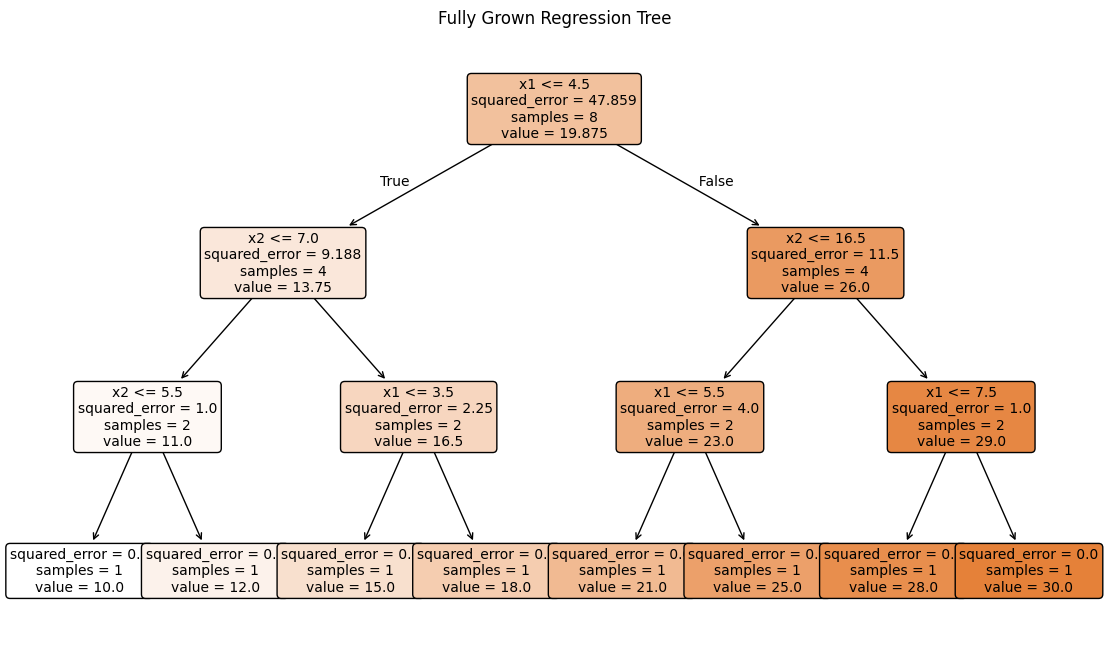

In [3]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

# Create dataset (from Q2)
x1 = np.array([1, 2, 3, 4, 5, 6, 7, 8])
x2 = np.array([5, 6, 8, 10, 12, 15, 18, 20])
y  = np.array([10, 12, 15, 18, 21, 25, 28, 30])

df = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'y': y
})

print("Dataset:\n", df)

X = df[['x1', 'x2']]   # Features
y = df['y']            # Target

# Fully grown regression tree
model = DecisionTreeRegressor(
    criterion='squared_error',  # SSE minimization
    max_depth=None,             # Fully grown
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

model.fit(X, y)

# Visualize the tree
plt.figure(figsize=(14,8))
plot_tree(
    model,
    feature_names=['x1', 'x2'],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Fully Grown Regression Tree")
plt.show()

QUESTION 8

In [ ]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

train_path = "A4_train.csv"
test_path = "A4_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train = train_df.drop(columns=["Label"])
y_train = train_df["Label"]

X_test = test_df.drop(columns=["Label"])
y_test = test_df["Label"]


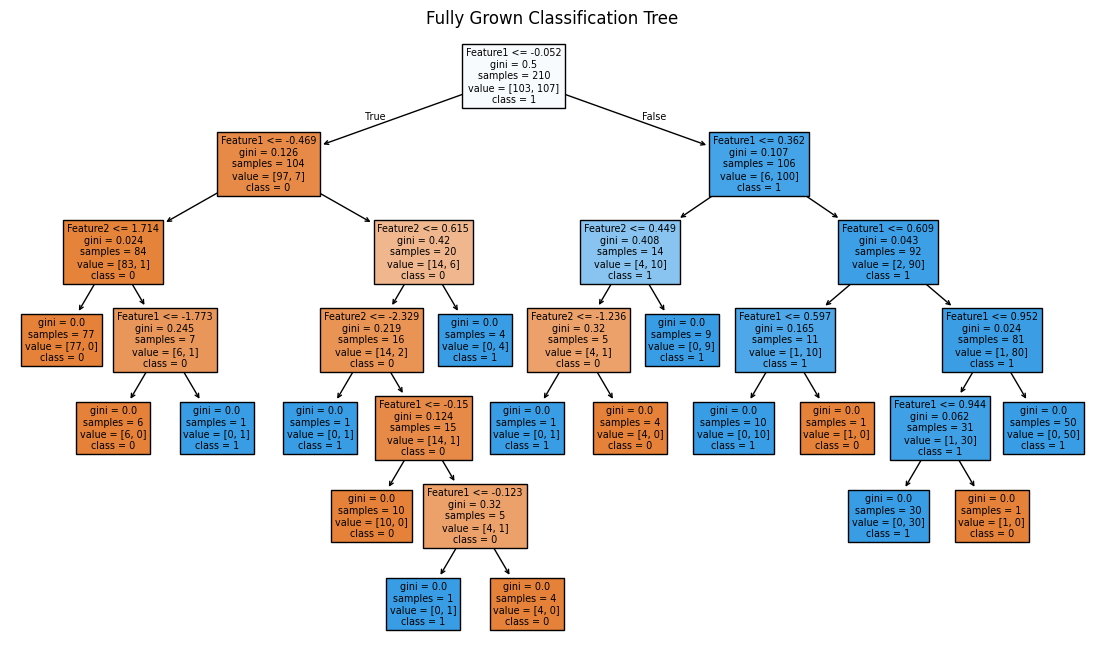

In [15]:
# (a) Fully grown tree
full_tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

full_tree.fit(X_train, y_train)

# Visualize full tree
plt.figure(figsize=(14,8))
plot_tree(full_tree, feature_names=X_train.columns, class_names=['0', '1'], filled=True)
plt.title("Fully Grown Classification Tree")
plt.show()


A fully grown classification tree was trained using Gini impurity with no restriction on depth. The tree continues splitting until all terminal nodes are pure or no further splits are possible, resulting in zero training error. However, such a model is highly complex and prone to overfitting.

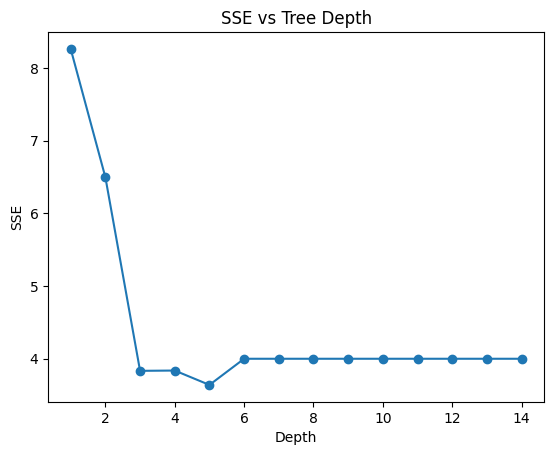

In [16]:
# (b) SSE vs depth
depths = range(1, 15)
sse_list = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    
    # use probability predictions for SSE
    probs = model.predict_proba(X_test)[:,1]
    sse = np.sum((y_test - probs)**2)
    sse_list.append(sse)

# Plot SSE vs depth
plt.figure()
plt.plot(depths, sse_list, marker='o')
plt.xlabel("Depth")
plt.ylabel("SSE")
plt.title("SSE vs Tree Depth")
plt.show()


The SSE decreases rapidly for small depths, indicating that the model is learning important structure in the data. Beyond a certain depth, the reduction in SSE becomes negligible, suggesting diminishing returns from further splits and limited improvement in generalization performance.

In [24]:
# (c) Find optimal depth 
optimal_depth = 5  # from elbow in graph

for d, s in zip(depths, sse_list):
    print(f"Depth {d}: SSE = {s:.3f}")
print("Optimal depth:", optimal_depth)


Depth 1: SSE = 8.264
Depth 2: SSE = 6.497
Depth 3: SSE = 3.834
Depth 4: SSE = 3.838
Depth 5: SSE = 3.640
Depth 6: SSE = 4.000
Depth 7: SSE = 4.000
Depth 8: SSE = 4.000
Depth 9: SSE = 4.000
Depth 10: SSE = 4.000
Depth 11: SSE = 4.000
Depth 12: SSE = 4.000
Depth 13: SSE = 4.000
Depth 14: SSE = 4.000
Optimal depth: 5


The optimal depth is chosen as 5 based on the elbow point in the SSE vs depth curve. Beyond this depth, the SSE shows minimal improvement and eventually stabilizes, indicating that additional splits do not significantly enhance predictive performance and may lead to overfitting.

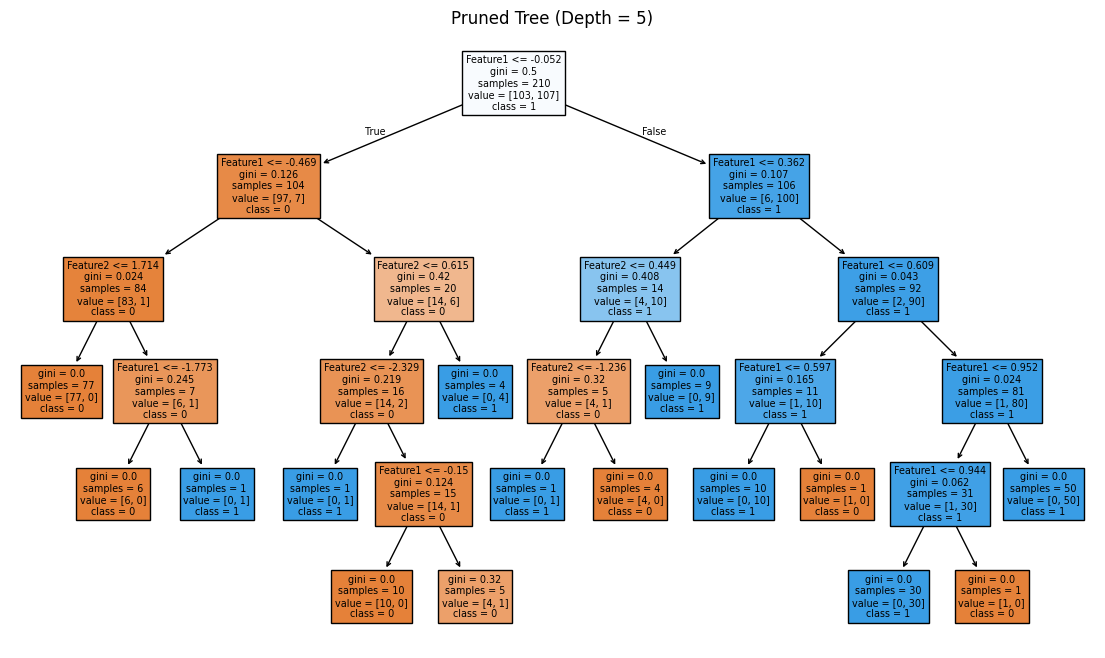

In [20]:
# (d) Train pruned tree
pruned_tree = DecisionTreeClassifier(max_depth=optimal_depth, random_state=42)
pruned_tree.fit(X_train, y_train)

# Visualize pruned tree
plt.figure(figsize=(14,8))
plot_tree(pruned_tree, feature_names=X_train.columns, class_names=['0', '1'], filled=True)
plt.title(f"Pruned Tree (Depth = {optimal_depth})")
plt.show()

The pruned tree with depth 5 retains the most informative splits while eliminating unnecessary branches. This reduces model complexity, mitigates overfitting, and results in better generalization to unseen data.

In [2]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt

train_path = "A4_train.csv"
test_path = "A4_test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

X_train = train_df.drop(columns=["Label"])
y_train = train_df["Label"]

X_test = test_df.drop(columns=["Label"])
y_test = test_df["Label"]


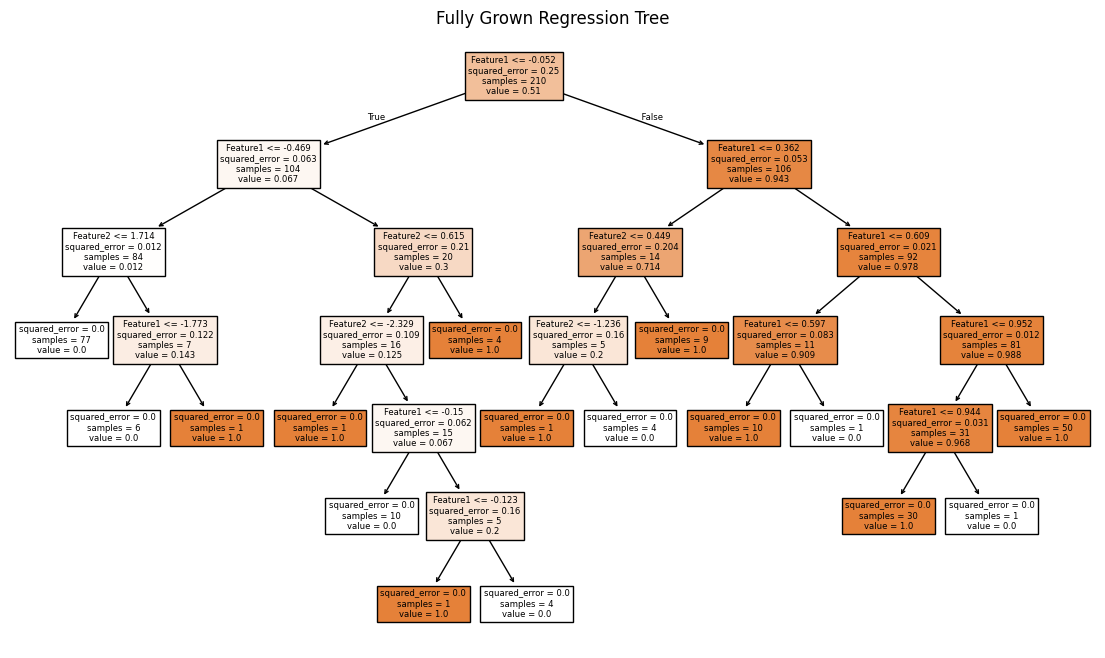

In [8]:
# (a) Fully grown tree
full_tree = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

full_tree.fit(X_train, y_train)

# Visualize full tree
plt.figure(figsize=(14,8))
plot_tree(full_tree, feature_names=X_train.columns, filled=True)
plt.title("Fully Grown Regression Tree")
plt.show()


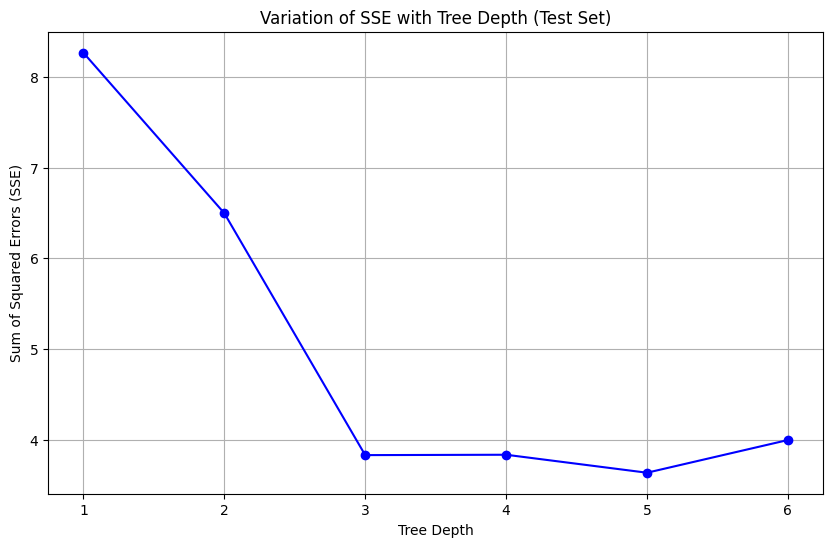

In [4]:
# 1. Determine the maximum depth of the fully grown tree
max_possible_depth = full_tree.get_depth()

depths = range(1, max_possible_depth + 1)
sse_values = []

# 2. Iterate through depths
for depth in depths:
    # Initialize and train the tree with specific depth
    tree = DecisionTreeRegressor(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    
    # Predict on test set
    y_pred = tree.predict(X_test)
    
    # Calculate SSE: sum((y_true - y_pred)^2)
    # Note: mean_squared_error * number_of_samples = SSE
    sse = np.sum((y_test - y_pred)**2)
    sse_values.append(sse)

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(depths, sse_values, marker='o', linestyle='-', color='b')
plt.title("Variation of SSE with Tree Depth (Test Set)")
plt.xlabel("Tree Depth")
plt.ylabel("Sum of Squared Errors (SSE)")
plt.grid(True)
plt.show()

In [9]:
optimal_depth = depths[np.argmin(sse_values)]
print(f"Optimal depth based on SSE: {optimal_depth}")

Optimal depth based on SSE: 5


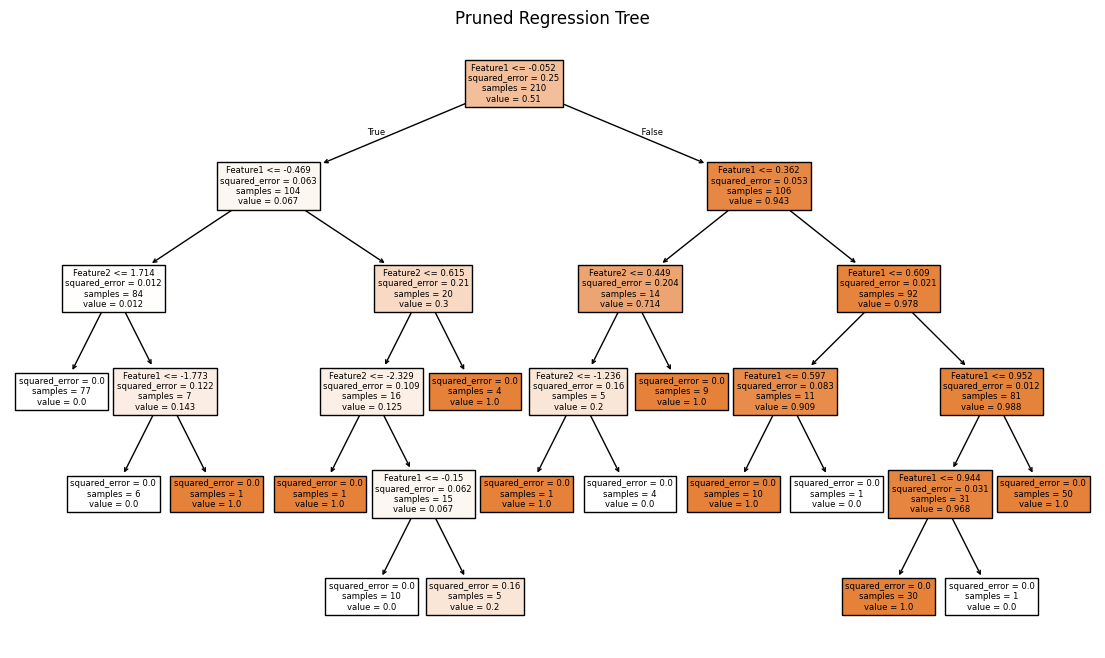

In [10]:
# (b) Prunedtree
pruned_regression_tree = DecisionTreeRegressor(
    criterion="squared_error",
    max_depth=optimal_depth,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

pruned_regression_tree.fit(X_train, y_train)

# Visualize pruned tree
plt.figure(figsize=(14,8))
plot_tree(pruned_regression_tree, feature_names=X_train.columns, filled=True)
plt.title("Pruned Regression Tree")
plt.show()
